<a href="https://colab.research.google.com/github/ifchandesh/employee_attrition_analysis/blob/main/employee_attrition_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Analysis & Prediction

This notebook analyzes employee turnover using the IBM HR Analytics dataset, identifies key factors driving resignation (Age, Salary, Department, etc.), builds classification models, and provides an interactive HR dashboard with KPIs.

## 1. Setup & Load Dataset

In [1]:
# Install dependencies if running in Google Colab
!pip install -q gradio plotly scikit-learn seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load IBM HR Analytics dataset
data_url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df = pd.read_csv(data_url)

# Drop uninformative / constant columns
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 1470 rows, 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## 2. Identify Factors Influencing Resignation (EDA)
We examine how **Age, Salary, Department, OverTime, and Job Satisfaction** impact employee turnover.

/tmp/ipykernel_428/2375282308.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ot_pct, x='OverTime', y='Attrition', palette='Reds', ax=axes[1, 0])
/tmp/ipykernel_428/2375282308.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sat_pct, x='JobSatisfaction', y='Attrition', palette='Blues_r', ax=axes[1, 1])


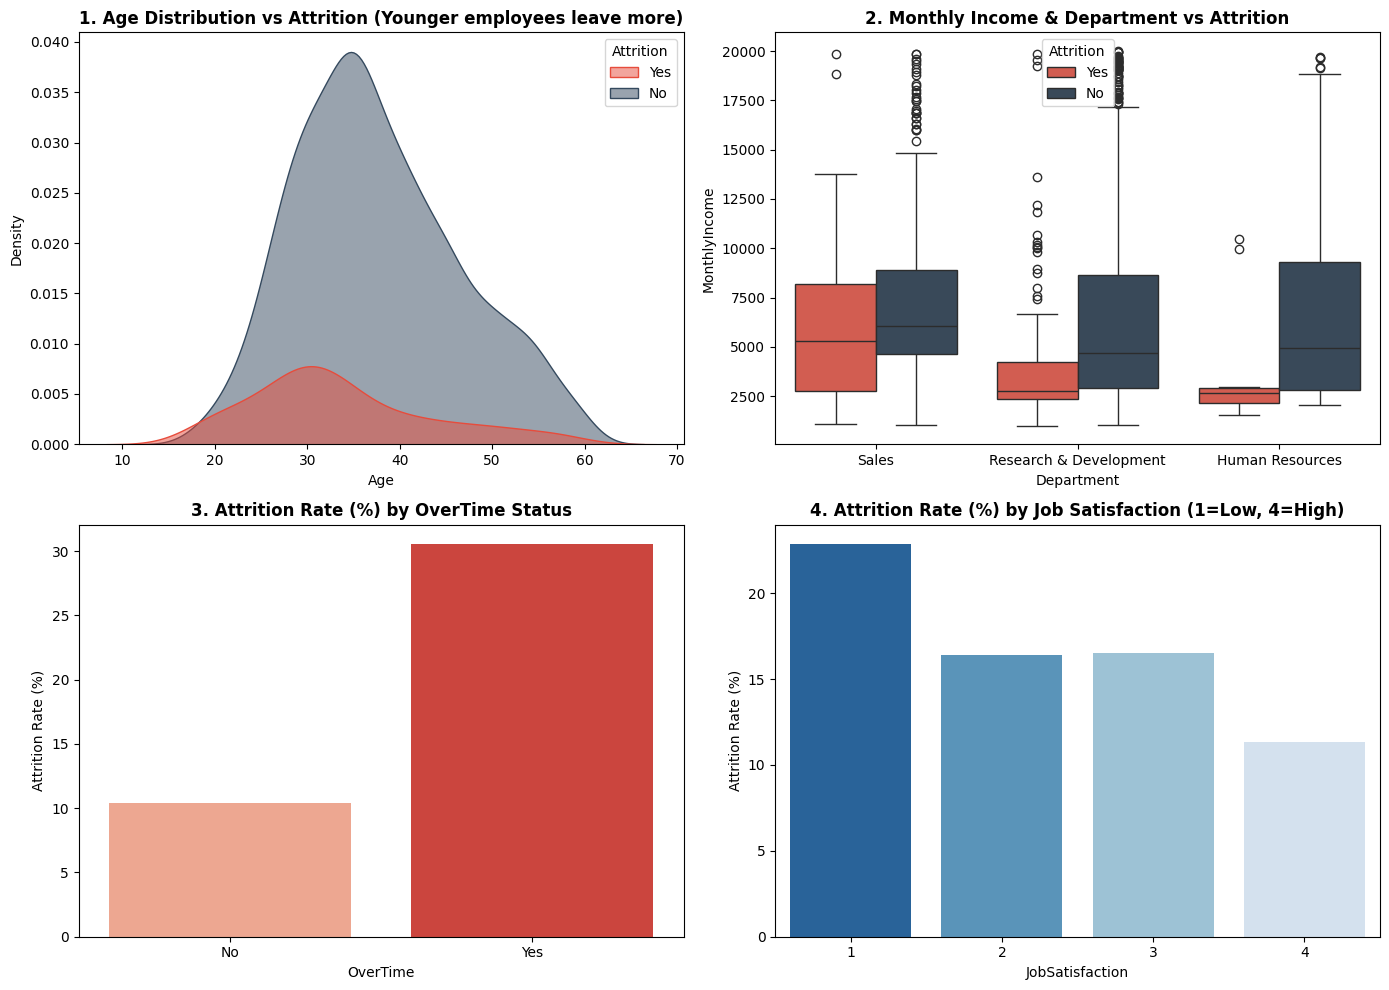

In [3]:
# Visualizing key factors influencing attrition
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette = {'Yes': '#e74c3c', 'No': '#34495e'}

# 1. Age Distribution
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, palette=palette, ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title("1. Age Distribution vs Attrition (Younger employees leave more)", fontweight='bold')

# 2. Monthly Income by Department
sns.boxplot(data=df, x='Department', y='MonthlyIncome', hue='Attrition', palette=palette, ax=axes[0, 1])
axes[0, 1].set_title("2. Monthly Income & Department vs Attrition", fontweight='bold')

# 3. OverTime Impact
ot_pct = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=ot_pct, x='OverTime', y='Attrition', palette='Reds', ax=axes[1, 0])
axes[1, 0].set_title("3. Attrition Rate (%) by OverTime Status", fontweight='bold')
axes[1, 0].set_ylabel("Attrition Rate (%)")

# 4. Job Satisfaction Impact
sat_pct = df.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=sat_pct, x='JobSatisfaction', y='Attrition', palette='Blues_r', ax=axes[1, 1])
axes[1, 1].set_title("4. Attrition Rate (%) by Job Satisfaction (1=Low, 4=High)", fontweight='bold')
axes[1, 1].set_ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

## 3. Classification Algorithms & Model Evaluation
We prepare features, train **Logistic Regression, Decision Tree, and Random Forest** models, and compare their performance.

In [4]:
# Prepare features and target
X = df.drop(columns=['Attrition'])
y = (df['Attrition'] == 'Yes').astype(int)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train and evaluate models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42)
}

results = []
trained_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 3)
    })
    trained_pipes[name] = pipe

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.752,0.349,0.638,0.451,0.803
1,Decision Tree,0.786,0.379,0.532,0.442,0.653
2,Random Forest,0.833,0.455,0.213,0.290,0.792


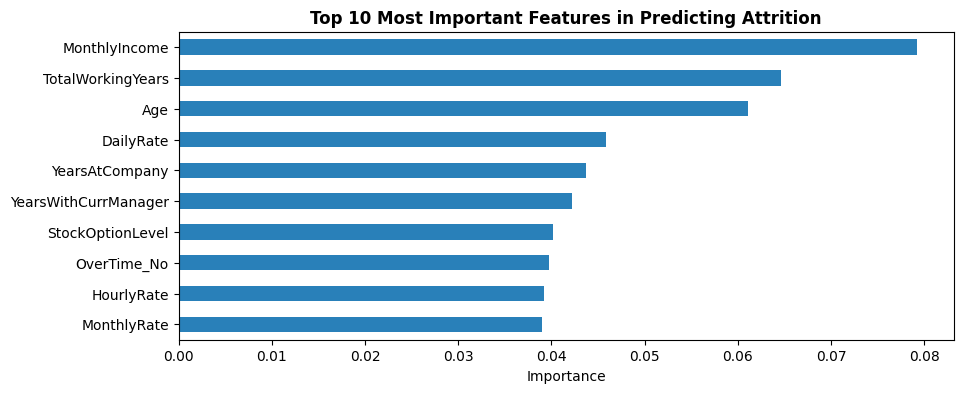

In [5]:
# Top Feature Importances from Random Forest
rf_model = trained_pipes['Random Forest'].named_steps['classifier']
encoded_cat_names = trained_pipes['Random Forest'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = num_cols + list(encoded_cat_names)

feat_imp = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
feat_imp.sort_values().plot(kind='barh', color='#2980b9')
plt.title("Top 10 Most Important Features in Predicting Attrition", fontweight='bold')
plt.xlabel("Importance")
plt.show()

## 4. HR KPI Dashboard & Flight Risk Predictor
An interactive dashboard displaying key HR metrics and allowing real-time prediction of employee flight risk.

In [6]:
# Compute HR KPIs
total_headcount = len(df)
total_attrition = (df['Attrition'] == 'Yes').sum()
attrition_rate = round((total_attrition / total_headcount) * 100, 1)
avg_income = round(df['MonthlyIncome'].mean(), 2)

best_pipe = trained_pipes['Random Forest']

def predict_attrition(age, department, job_role, monthly_income, overtime, job_satisfaction, years_at_company):
    sample = pd.DataFrame([{
        'Age': age,
        'BusinessTravel': 'Travel_Rarely',
        'DailyRate': 800,
        'Department': department,
        'DistanceFromHome': 10,
        'Education': 3,
        'EducationField': 'Life Sciences',
        'EnvironmentSatisfaction': 3,
        'Gender': 'Male',
        'HourlyRate': 65,
        'JobInvolvement': 3,
        'JobLevel': 2,
        'JobRole': job_role,
        'JobSatisfaction': job_satisfaction,
        'MaritalStatus': 'Single',
        'MonthlyIncome': monthly_income,
        'MonthlyRate': 14000,
        'NumCompaniesWorked': 2,
        'OverTime': overtime,
        'PercentSalaryHike': 15,
        'PerformanceRating': 3,
        'RelationshipSatisfaction': 3,
        'StockOptionLevel': 0,
        'TotalWorkingYears': max(1, age - 20),
        'TrainingTimesLastYear': 3,
        'WorkLifeBalance': 2,
        'YearsAtCompany': years_at_company,
        'YearsInCurrentRole': max(0, years_at_company - 1),
        'YearsSinceLastPromotion': 1,
        'YearsWithCurrManager': max(0, years_at_company - 1)
    }])

    prob = best_pipe.predict_proba(sample)[0][1]
    prob_pct = round(prob * 100, 1)
    status = "High Risk (Likely to leave)" if prob_pct >= 50 else ("Moderate Risk" if prob_pct >= 25 else "Low Risk (Likely to stay)")
    return f"{prob_pct}%", status

# Create Gradio Dashboard
with gr.Blocks(title="HR Attrition Dashboard") as demo:
    gr.Markdown("# HR Employee Attrition Dashboard")

    # KPI Cards
    with gr.Row():
        gr.Textbox(value=f"{total_headcount}", label="Total Employees", interactive=False)
        gr.Textbox(value=f"{attrition_rate}% ({total_attrition} resigned)", label="Overall Attrition Rate", interactive=False)
        gr.Textbox(value=f"${avg_income:,}", label="Average Monthly Income", interactive=False)

    # Predictor Controls
    gr.Markdown("### Employee Flight Risk Predictor")
    with gr.Row():
        with gr.Column():
            age_in = gr.Slider(18, 65, value=30, step=1, label="Age")
            dept_in = gr.Dropdown(['Sales', 'Research & Development', 'Human Resources'], value='Sales', label="Department")
            role_in = gr.Dropdown(['Sales Executive', 'Sales Representative', 'Research Scientist', 'Laboratory Technician', 'Manager'], value='Sales Representative', label="Job Role")
            income_in = gr.Slider(1000, 20000, value=3000, step=100, label="Monthly Income ($)")
        with gr.Column():
            ot_in = gr.Radio(['Yes', 'No'], value='Yes', label="OverTime")
            sat_in = gr.Slider(1, 4, value=2, step=1, label="Job Satisfaction (1=Low, 4=High)")
            tenure_in = gr.Slider(0, 40, value=2, step=1, label="Years at Company")

    predict_btn = gr.Button("Predict Flight Risk", variant="primary")

    with gr.Row():
        out_prob = gr.Textbox(label="Attrition Probability")
        out_status = gr.Textbox(label="Risk Level")

    predict_btn.click(predict_attrition, inputs=[age_in, dept_in, role_in, income_in, ot_in, sat_in, tenure_in], outputs=[out_prob, out_status])

# Launch Dashboard in Colab
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1b5e66709e7e3f690a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
